# Data Exploration for iFood 2019 Dataset

In this notebook we download the iFood 2019 dataset from Kaggle, extract it, look at how the classes are distributed, split the training data into a training and validation set, and check some basic properties of the images such as size, color mode and corruption before moving to model training.

In [ ]:
import os
import glob
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from collections import Counter
from tqdm import tqdm



## Downloading the Dataset from Kaggle

We use the Kaggle API to get the data straight into the Colab machine instead of going through Google Drive, since Drive is much slower when dealing with a large number of files. We paste our API token when asked, it will not be saved anywhere in the notebook.

In [ ]:
os.environ['KAGGLE_API_TOKEN'] = 'your_token'

!pip install -q kaggle
!kaggle competitions download -c ifood-2019-fgvc6 -p /content/ifood_raw

ifood-2019-fgvc6.zip: Skipping, found more recently modified local copy (use --force to force download)


## Extracting the main zip file

The download gives us one big zip file. We unzip it into a working folder
called ifood. Inside we expect to find the csv files with labels and the
smaller zip files for train, validation and test images.

In [ ]:
extract_path = '/content/ifood/'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile('/content/ifood_raw/ifood-2019-fgvc6.zip', 'r') as zf:
    zf.extractall(extract_path)

!ls -la {extract_path}

total 3001936
drwxr-xr-x 4 root root       4096 Aug  1 06:29 .
drwxr-xr-x 1 root root       4096 Aug  1 06:26 ..
-rw-r--r-- 1 root root       3717 Aug  1 06:59 class_list.txt
-rw-r--r-- 1 root root     567555 Aug  1 06:59 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug  1 06:59 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug  1 06:59 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug  1 06:59 train_labels.csv
drwxr-xr-x 2 root root    4145152 Aug  1 06:28 train_set
-rw-r--r-- 1 root root 2277605678 Aug  1 07:00 train_set.zip
-rw-r--r-- 1 root root    2802442 Aug  1 06:50 train_split.csv
-rw-r--r-- 1 root root     222409 Aug  1 07:00 val_labels.csv
drwxr-xr-x 2 root root     442368 Aug  1 06:28 val_set
-rw-r--r-- 1 root root  232027129 Aug  1 07:00 val_set.zip
-rw-r--r-- 1 root root    1201068 Aug  1 06:50 val_split.csv


## Extracting train and validation images

We do not need the test set because we do not have labels for it and we
are not going to submit anything to the competition. We will use the
official validation images as our own test set later, and we will build
our own train and validation split out of the training images.

In [ ]:
for z in ['train_set.zip', 'val_set.zip']:
    print(f"Extract {z}...")
    with zipfile.ZipFile(f'/content/ifood/{z}', 'r') as zf:
        zf.extractall('/content/ifood/')

!ls -la /content/ifood/

Extract train_set.zip...
Extract val_set.zip...
total 3001936
drwxr-xr-x 4 root root       4096 Aug  1 06:29 .
drwxr-xr-x 1 root root       4096 Aug  1 06:26 ..
-rw-r--r-- 1 root root       3717 Aug  1 06:59 class_list.txt
-rw-r--r-- 1 root root     567555 Aug  1 06:59 ifood2019_sample_submission.csv
-rw-r--r-- 1 root root     567555 Aug  1 06:59 sample_submission.csv
-rw-r--r-- 1 root root  551912960 Aug  1 06:59 test_set.zip
-rw-r--r-- 1 root root    2435315 Aug  1 06:59 train_labels.csv
drwxr-xr-x 2 root root    4145152 Aug  1 06:28 train_set
-rw-r--r-- 1 root root 2277605678 Aug  1 07:00 train_set.zip
-rw-r--r-- 1 root root    2802442 Aug  1 06:50 train_split.csv
-rw-r--r-- 1 root root     222409 Aug  1 07:00 val_labels.csv
drwxr-xr-x 2 root root     442368 Aug  1 06:28 val_set
-rw-r--r-- 1 root root  232027129 Aug  1 07:00 val_set.zip
-rw-r--r-- 1 root root    1201068 Aug  1 06:50 val_split.csv


## Function to load the labels

The csv files have two columns, img_name and label. We rename img_name to
image_name so it matches what the rest of our functions expect. We also
load the class list file which tells us the food name for each numeric
label.

In [ ]:
def load_data(csv_path, class_list_path):
    data = pd.read_csv(csv_path)
    data = data.rename(columns={"img_name": "image_name"})

    class_file = open(class_list_path, "r")
    classes = []
    for line in class_file:
        classes.append(line.strip())
    class_file.close()

    names = []
    for label in data["label"]:
        names.append(classes[label])
    data["class_name"] = names

    return data, classes


## Function to plot how many images each class has

Some food categories will have a lot more pictures than others. This
function counts images per class and shows three plots, the full
distribution, the classes with the most images and the classes with the
least images, plus some basic numbers printed below.

In [ ]:
def plot_class_distribution(data, title="Class distribution", top_n=10):
    counts = data["label"].value_counts().sort_values(ascending=False)
    name_of = dict(zip(data["label"], data["class_name"]))

    top = counts.head(top_n)
    bottom = counts.tail(top_n)

    fig, axes = plt.subplots(3, 1, figsize=(24, 10))

    axes[0].bar(range(len(counts)), counts.values, color="steelblue")
    axes[0].set_title(title)
    axes[0].set_ylabel("Number of images")
    axes[0].axhline(counts.mean(), color="red", linestyle="--", label="mean")
    axes[0].axhline(counts.median(), color="orange", linestyle="--", label="median")
    axes[0].set_xticks([])
    axes[0].legend()

    axes[1].bar([name_of[i] for i in top.index], top.values, color="steelblue")
    axes[1].set_title("Classes with most images")
    axes[1].tick_params(axis="x", rotation=45)

    axes[2].bar([name_of[i] for i in bottom.index], bottom.values, color="salmon")
    axes[2].set_title("Classes with fewest images")
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    print("min images per class:", counts.min())
    print("max images per class:", counts.max())
    print("mean images per class:", round(counts.mean(), 1))
    print("median images per class:", counts.median())

## Functions to balance the dataset with a cap

Since some classes are much bigger than others, we set a maximum number of
images per class. The cap value is taken from a percentile of the class
counts, so it is chosen automatically from the data instead of picked by
hand. Classes with more images than the cap get randomly reduced.

In [ ]:
def choose_cap(data, percentile=70):
    counts = data["label"].value_counts()
    cap = int(counts.quantile(percentile / 100))
    print("cap value:", cap)
    print("classes above cap:", (counts > cap).sum())
    return cap


def apply_cap(data, cap):
    groups = []
    for label, group in data.groupby("label"):
        if len(group) > cap:
            group = group.sample(cap, random_state=42)
        groups.append(group)
    result = pd.concat(groups)
    return result.reset_index(drop=True)

## Function to split into train and validation

We use a stratified split so each class keeps roughly the same proportion
of images in both the training set and the validation set. This matters
because some classes already have very few images.

In [ ]:
def stratified_split(data, val_size=0.2, seed=42):
    train_data, val_data = train_test_split(
        data,
        test_size=val_size,
        stratify=data["label"],
        random_state=seed
    )
    train_data = train_data.reset_index(drop=True)
    val_data = val_data.reset_index(drop=True)
    return train_data, val_data

## Function to look at some example images

Before checking numbers it helps to actually look at a few pictures from
random classes, just to get a feeling of what the dataset looks like.

In [ ]:
def plot_sample_images(data, img_folder, n_classes=5, n_images=4):
    labels = data["label"].drop_duplicates().sample(n_classes, random_state=42)
    fig, axes = plt.subplots(n_classes, n_images, figsize=(n_images * 3, n_classes * 3))

    row = 0
    for label in labels:
        subset = data[data["label"] == label].sample(n_images, random_state=42)
        class_name = subset["class_name"].values[0]

        col = 0
        for i, r in subset.iterrows():
            img = Image.open(img_folder + r["image_name"])
            axes[row, col].imshow(img)
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(class_name, fontsize=9, loc="left")
            col = col + 1
        row = row + 1

    plt.tight_layout()
    plt.show()

## Functions to check image properties

These functions look at a random sample of images and check width and
height, aspect ratio, color mode and whether the file can even be opened
without errors. We do this on a sample instead of the whole dataset
because opening a hundred thousand images just to check basic stats would
take too long and is not really necessary for exploration.

In [ ]:
def plot_image_sizes(data, img_folder, sample_size=500):
    sample = data.sample(sample_size, random_state=42)
    widths = []
    heights = []

    for i, r in sample.iterrows():
        path = os.path.join(img_folder, r["image_name"])
        try:
            img = Image.open(path)
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except:
            pass

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(widths, bins=30, color="steelblue")
    axes[0].set_title("Width")
    axes[1].hist(heights, bins=30, color="steelblue")
    axes[1].set_title("Height")
    plt.show()

    print("mean width:", round(np.mean(widths)))
    print("mean height:", round(np.mean(heights)))
    print("min size:", min(widths), "by", min(heights))
    print("max size:", max(widths), "by", max(heights))


def plot_aspect_ratio(data, img_folder, sample_size=500):
    sample = data.sample(sample_size, random_state=42)
    ratios = []

    for i, r in sample.iterrows():
        path = os.path.join(img_folder, r["image_name"])
        try:
            img = Image.open(path)
            w, h = img.size
            ratios.append(w / h)
        except:
            pass

    plt.figure(figsize=(8, 4))
    plt.hist(ratios, bins=30, color="steelblue")
    plt.axvline(1.0, color="red", linestyle="--", label="square")
    plt.title("Aspect ratio")
    plt.legend()
    plt.show()


def check_image_modes(data, img_folder, sample_size=200):
    sample = data.sample(sample_size, random_state=42)
    modes = []

    for i, r in sample.iterrows():
        try:
            img = Image.open(img_folder + r["image_name"])
            modes.append(img.mode)
        except:
            pass

    counts = Counter(modes)
    print("modes found:", counts)
    plt.bar(counts.keys(), counts.values(), color="steelblue")
    plt.title("Color modes")
    plt.show()


def check_corrupted_images(data, img_folder, sample_size=500):
    sample = data.sample(sample_size, random_state=42)
    bad_files = []

    for i, r in sample.iterrows():
        try:
            img = Image.open(img_folder + r["image_name"])
            img.verify()
        except:
            bad_files.append(r["image_name"])

    percent = len(bad_files) / sample_size * 100
    print("corrupted images found:", len(bad_files), "out of", sample_size, "which is", round(percent, 1), "percent")
    return bad_files

## Loading the actual data

We now load the training labels, which we are going to split ourselves,
and the official validation labels, which we keep aside as our own test
set since it has human verified labels and we are never going to train on
it or tune anything based on it.

In [ ]:
data_root = "/content/ifood/"

train_pool, classes = load_data(data_root + "train_labels.csv", data_root + "class_list.txt")
test_data, _ = load_data(data_root + "val_labels.csv", data_root + "class_list.txt")

train_img_folder = data_root + "train_set/"
test_img_folder = data_root + "val_set/"

print("images available to split into train and val:", len(train_pool))
print("images kept as final test set:", len(test_data))

images available to split into train and val: 118475
images kept as final test set: 11994


## Looking at the class distribution before doing anything else

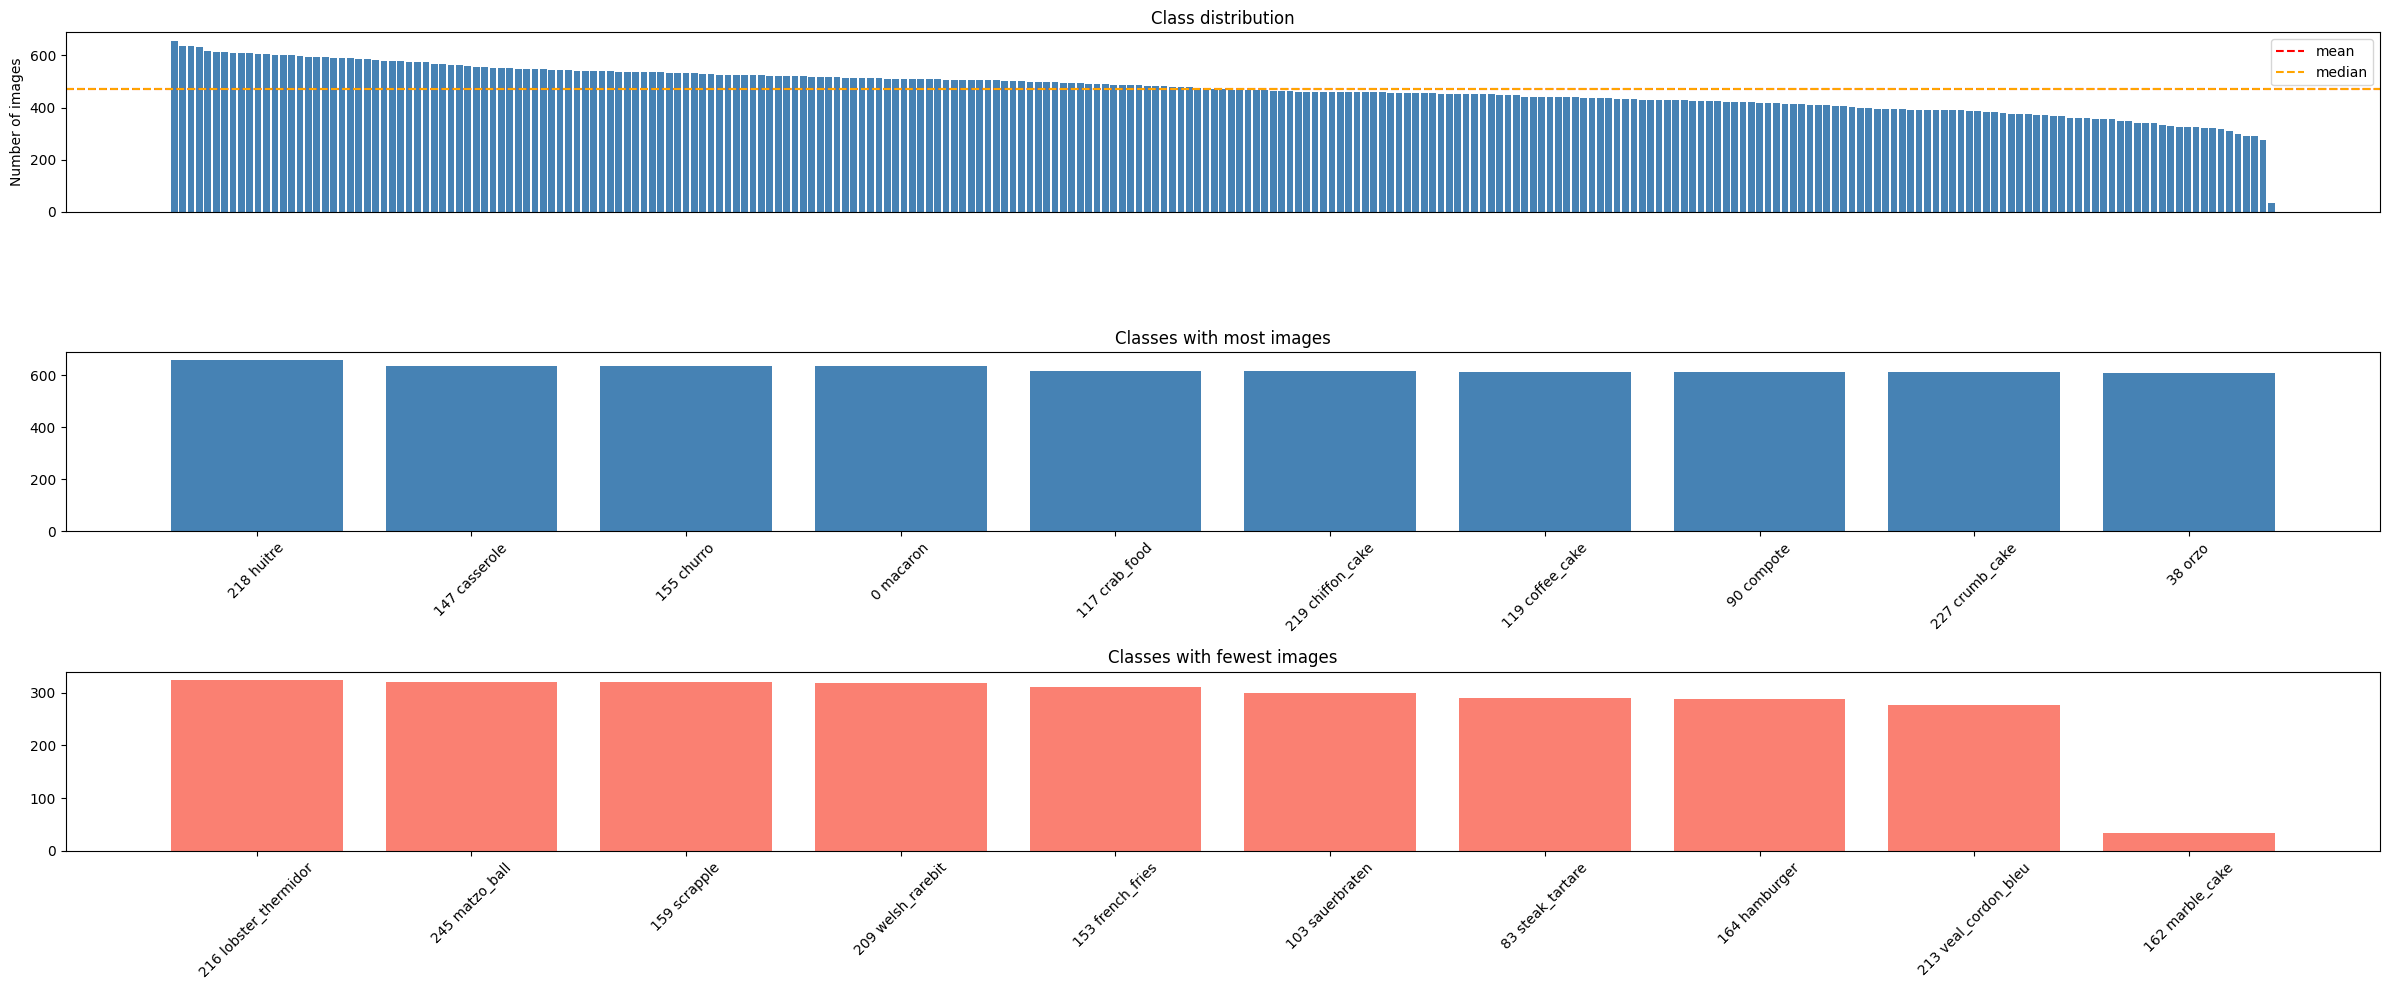

min images per class: 34
max images per class: 656
mean images per class: 472.0
median images per class: 471.0


In [ ]:
plot_class_distribution(train_pool)

The class distribution is not as unbalanced as We expected. Looking at the top plot, most classes sit somewhere between 300 and 600 images, without huge spikes or classes with almost nothing. The gap between mean and median is small, which also points to a fairly even distribution overall.

The richest classes (huitre, casserole, churro, macaron) all have around 600 images.

The poorest classes (lobster thermidor, matzo ball, scrapple, welsh rarebit) still have a reasonable amount of images, generally above 200, except for marble cake which drops much lower than the rest and stands out as an outlier in the bottom plot.

Given this, a moderate cap should be enough to balance things out without throwing away too much data, and marble cake is the one class worth keeping an eye on later since it might behave differently during training due to having fewer examples.

##Applying a cap to reduce class imbalance

cap value: 500
classes above cap: 100


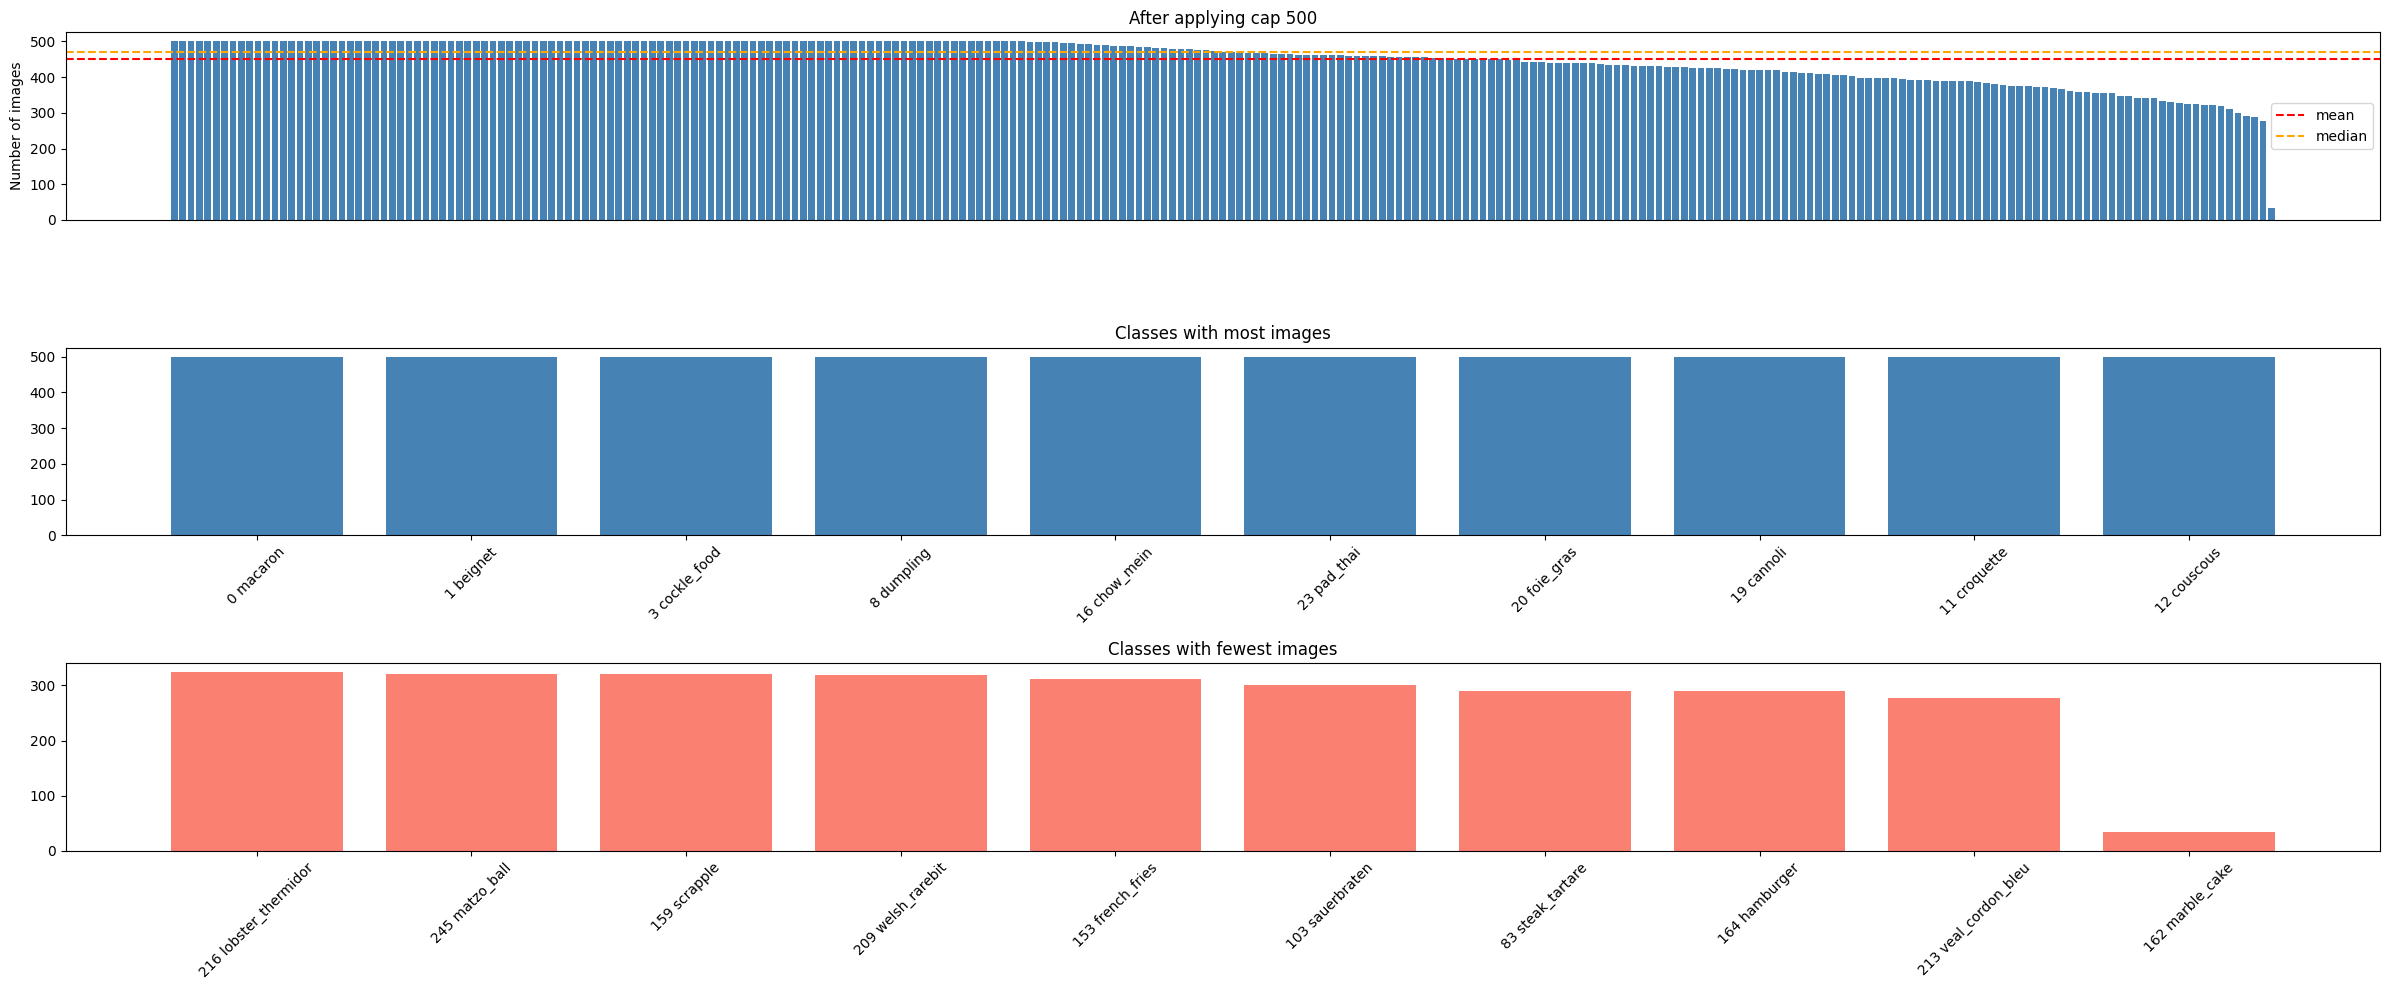

min images per class: 34
max images per class: 500
mean images per class: 451.5
median images per class: 471.0
images left after cap: 113325


In [ ]:
cap_value = choose_cap(train_pool, percentile=60)
train_pool_capped = apply_cap(train_pool, cap_value)
plot_class_distribution(train_pool_capped, title="After applying cap " + str(cap_value))
print("images left after cap:", len(train_pool_capped))

With a cap of 500, the top of the distribution gets flattened, all the richest classes now sit right at 500 instead of going up to 600 like before. This is visible in the top plot, where the highest bars are now all lined up at the same height.

The poorest classes did not change at all compared to the previous plot, which makes sense since the cap only removes images from classes that go over it, it does not add anything to the ones with fewer images. Marble cake is still the clear outlier at the bottom.

Mean and median got closer to each other after the cap, so the overall balance is better than before, even if the smallest classes are still much smaller than the rest. This gap between richest and poorest classes is something to keep in mind, but fixing it further would mean either accepting an even lower cap, which throws away a lot of data from the bigger classes, or looking into oversampling the smaller ones later during training.

## Splitting into train and validation

In [ ]:
train_data, val_data = stratified_split(train_pool_capped, val_size=0.3)

print("train size:", len(train_data))
print("val size:", len(val_data))
print("train classes:", train_data["label"].nunique())
print("val classes:", val_data["label"].nunique())

min_train = train_data["label"].value_counts().min()
min_val = val_data["label"].value_counts().min()
print("min images per class in train:", min_train)
print("min images per class in val:", min_val)

train_data.to_csv(data_root + "train_split.csv", index=False)
val_data.to_csv(data_root + "val_split.csv", index=False)
print("splits saved to csv")

train size: 79327
val size: 33998
train classes: 251
val classes: 251
min images per class in train: 24
min images per class in val: 10
splits saved to csv


After the cap and the stratified split, every one of the 251 classes is present in both train and validation, so the split did what it was supposed to do, no class disappeared.

The min images per class does raise a small concern though, with only 10 images in validation for the smallest class, marble cake most likely. That is a very small number to judge performance on for that one class, results for it will probably be noisy no matter what the model does. It is not a big enough problem to redo the split, but worth remembering when looking at per class metrics later, one bad prediction on that class will swing its accuracy a lot more than for classes with hundreds of images.

Overall the split ratio looks right too, around 70 percent train and 30 percent val, matching what was set in the function call.

## Checking image sizes

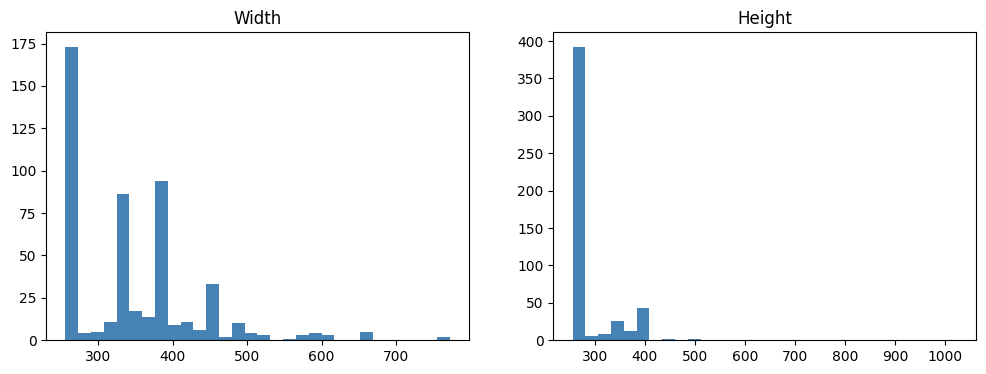

mean width: 347
mean height: 285
min size: 256 by 256
max size: 772 by 1024


In [ ]:
plot_image_sizes(train_data, train_img_folder, sample_size=500)

Most images are close to 256 by 256, which shows up as the tall first bar in both histograms, and that also matches the min size printed below, 256 by 256. So there is a clear minimum the dataset seems to respect, probably images were resized down to at least that before being uploaded to Kaggle.

After that first spike the width spreads out a bit more than the height, with clusters around 300 and 400, some images stretching all the way to 772. Height stays much more concentrated close to 256 to 300, with only a few outliers going up to 1024.

Mean width is 347 and mean height is 285, so on average images are a bit wider than tall, which lines up with what came out later in the aspect ratio check. Since sizes are not fixed and vary quite a bit, especially in width, resizing everything to a common square size before feeding it into a model will be necessary, something like 224 by 224 seems reasonable given where most of the mass of the distribution sits.

## Checking aspect ratio

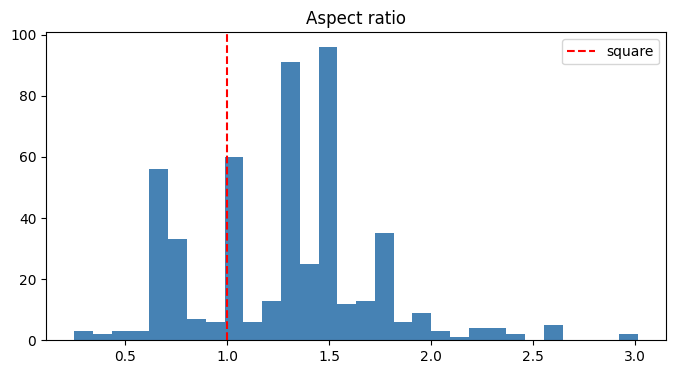

In [ ]:
plot_aspect_ratio(train_data, train_img_folder, sample_size=500)

The aspect ratio plot confirms what the width and height numbers already suggested, most images lean slightly landscape, with the biggest cluster sitting between 1.2 and 1.6, clearly past the square line at 1.0. There are also a decent number of images close to 1.0, so plenty of near square pictures too, just not the majority.

Nothing extreme shows up here, the tail beyond 2.5 is small and does not really affect the overall shape. This is useful for later, since it means a center crop before resizing to a square should not cut off important parts of the food in most images, the shapes are not wildly different from square to begin with.

On the color modes side, all 200 sampled images came back as RGB, no grayscale or RGBA mixed in. That is convenient, it means no extra conversion step is needed before feeding images into a model that expects three channels, at least based on this sample.

## Checking color modes

modes found: Counter({'RGB': 200})


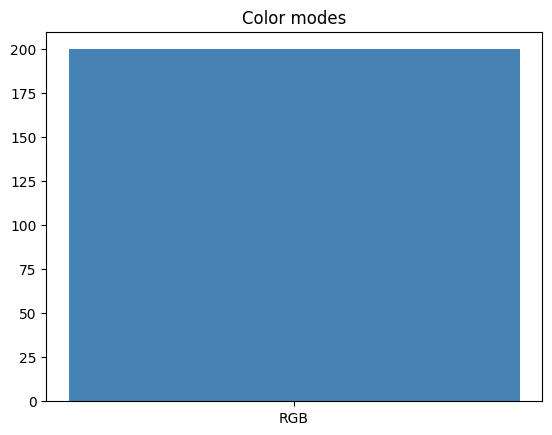

In [ ]:
check_image_modes(train_data, train_img_folder, sample_size=200)

This just confirms with a bar chart what the printed counter already said, all 200 sampled images are RGB, nothing else shows up at all. A single bar filling the whole plot is basically the best case scenario here, it means there is no need to handle grayscale or RGBA conversion in the preprocessing pipeline, at least not based on this sample. Still, this was checked on 200 images out of the full training set, so it is possible a few grayscale or RGBA images exist elsewhere and just were not picked up here, worth keeping a generic conversion to RGB in the loading pipeline anyway as a safety net rather than assuming the whole dataset is guaranteed to be RGB.

## Checking for corrupted images

In [ ]:
bad_files = check_corrupted_images(train_data, train_img_folder, sample_size=200)

corrupted images found: 0 out of 200 which is 0.0 percent


No corrupted images found in the sample, all 200 files opened and passed the integrity check without any error. This is a good sign, it means the download and extraction from Kaggle went through cleanly and there is no need to add any filtering step to remove broken files before training.

As with the color mode check, this is based on a sample rather than the full dataset, so it does not fully rule out a corrupted file existing somewhere in the remaining images. Still, 0 out of 200 is a reasonable signal that the dataset overall is in good shape, and wrapping image loading in a try except during training is still a sensible safety measure regardless of what this check found.

## Looking at some sample images from a few classes

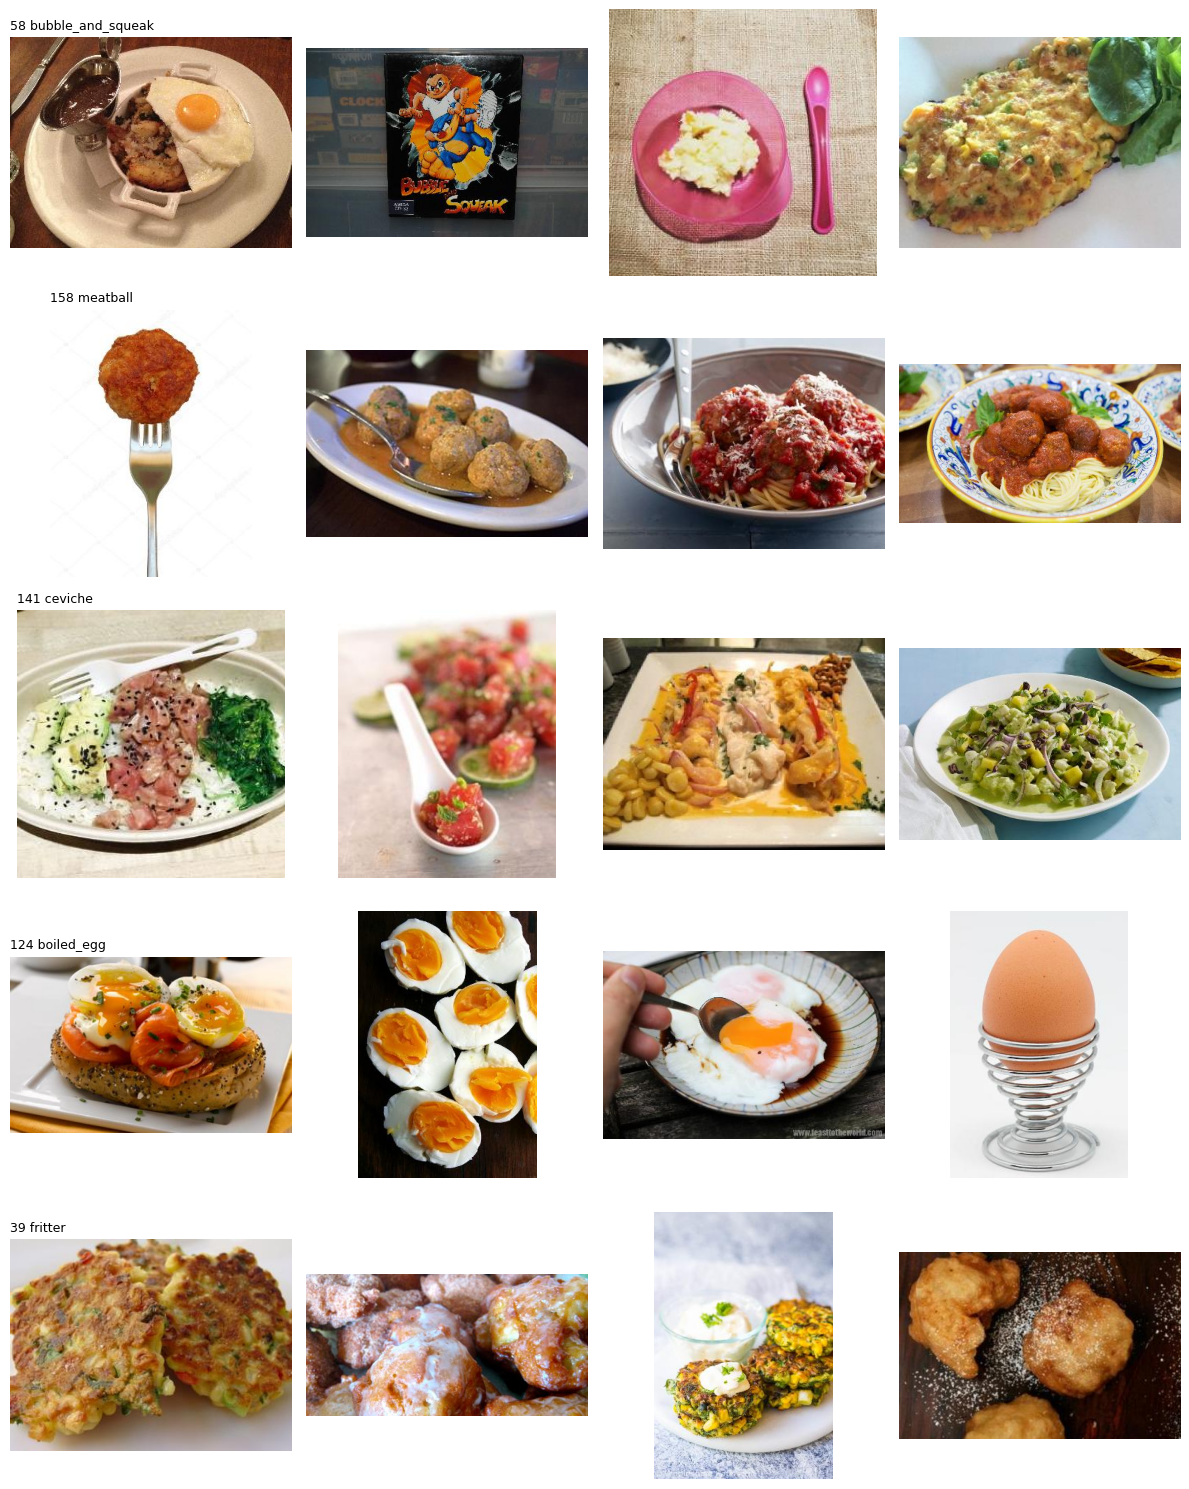

In [ ]:
plot_sample_images(train_data, train_img_folder, n_classes=5, n_images=4)